# Forecasting Net Prophet

You’re a growth analyst at [MercadoLibre](http://investor.mercadolibre.com/about-us). With over 200 million users, MercadoLibre is the most popular e-commerce site in Latin America. You've been tasked with analyzing the company's financial and user data in clever ways to make the company grow. So, you want to find out if the ability to predict search traffic can translate into the ability to successfully trade the stock.

The instructions for this Challenge are divided into four steps, as follows:

* Step 1: Find unusual patterns in hourly Google search traffic

* Step 2: Mine the search traffic data for seasonality

* Step 3: Relate the search traffic to stock price patterns

* Step 4: Create a time series model with Prophet

The following subsections detail these steps.

## Install and import the required libraries and dependencies

In [1]:
# Install the required libraries
!pip install prophet

In [2]:
# Import the required libraries and dependencies
import pandas as pd
from prophet import Prophet
import datetime as dt
import numpy as np
%matplotlib inline

## Step 1: Find Unusual Patterns in Hourly Google Search Traffic

The data science manager asks if the Google search traffic for the company links to any financial events at the company. Or, does the search traffic data just present random noise? To answer this question, pick out any unusual patterns in the Google search data for the company, and connect them to the corporate financial events.

To do so, complete the following steps:

1. Read the search data into a DataFrame, and then slice the data to just the month of May 2020. (During this month, MercadoLibre released its quarterly financial results.) Visualize the results. Do any unusual patterns exist?

2. Calculate the total search traffic for the month, and then compare the value to the monthly median across all months. Did the Google search traffic increase during the month that MercadoLibre released its financial results?


#### Step 1: Read the search data into a DataFrame, and then slice the data to just the month of May 2020. (During this month, MercadoLibre released its quarterly financial results.) Visualize the results. Do any unusual patterns exist?

In [3]:
# Store the data in a Pandas DataFrame
# Set the "Date" column as the Datetime Index.

df_mercado_trends = pd.read_csv(
    "https://static.bc-edx.com/ai/ail-v-1-0/m8/lms/datasets/google_hourly_search_trends.csv",
    index_col='Date',
    parse_dates=True
).dropna()

# Review the first and last five rows of the DataFrame
print("firt rows")
display(df_mercado_trends.head())
print ("last rows")
display(df_mercado_trends.tail())

/var/folders/zg/f4h5h8796cgbm5xkdx030gjh0000gn/T/ipykernel_89999/2435566790.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_mercado_trends = pd.read_csv(


firt rows


,Search Trends
Date,
2016-06-01 00:00:00,97
2016-06-01 01:00:00,92
2016-06-01 02:00:00,76
2016-06-01 03:00:00,60
2016-06-01 04:00:00,38


last rows


,Search Trends
Date,
2020-09-07 20:00:00,71
2020-09-07 21:00:00,83
2020-09-07 22:00:00,96
2020-09-07 23:00:00,97
2020-09-08 00:00:00,96


In [4]:
# Review the data types of the DataFrame using the info function
df_mercado_trends.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 37106 entries, 2016-06-01 00:00:00 to 2020-09-08 00:00:00
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Search Trends  37106 non-null  int64
dtypes: int64(1)
memory usage: 579.8 KB


In [5]:
import matplotlib.pyplot as plt

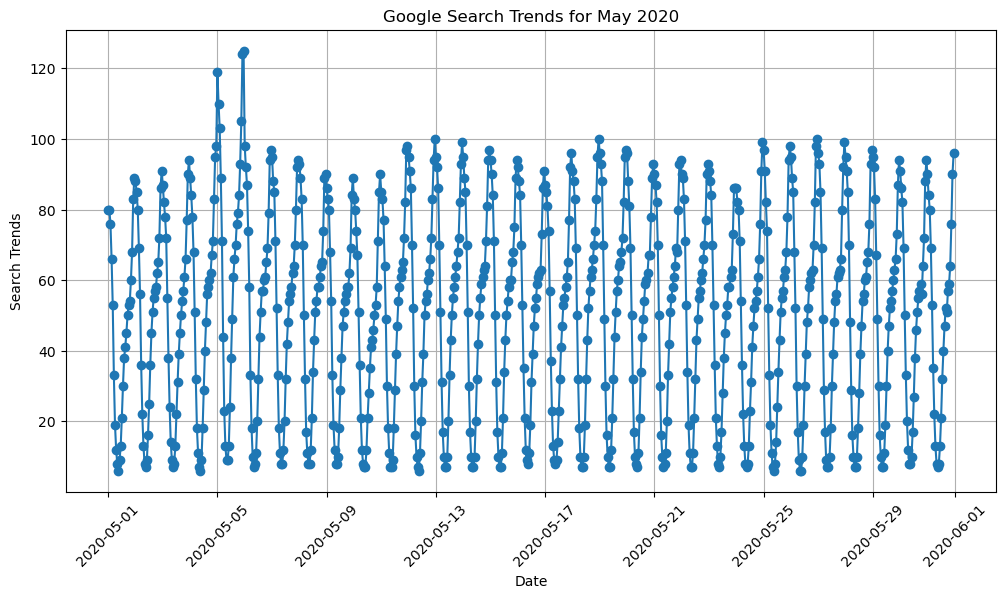

In [6]:
# Slice the DataFrame to just the month of May 2020
df_may_2020 = df_mercado_trends.loc['2020-05-01':'2020-05-31']

# Plot to visualize the data for May 2020
plt.figure(figsize=(12, 6))
plt.plot(df_may_2020.index, df_may_2020['Search Trends'], marker='o', linestyle='-')
plt.title('Google Search Trends for May 2020')
plt.xlabel('Date')
plt.ylabel('Search Trends')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


#### Step 2: Calculate the total search traffic for the month, and then compare the value to the monthly median across all months. Did the Google search traffic increase during the month that MercadoLibre released its financial results?

Total search traffic for May 2020: 38181
Median monthly total search traffic across all months: 35172.5
Did the Google search traffic increase during the month that MercadoLibre released its financial results? True


/var/folders/zg/f4h5h8796cgbm5xkdx030gjh0000gn/T/ipykernel_89999/2315119805.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_total_search_traffic = df_mercado_trends.resample('M').sum()


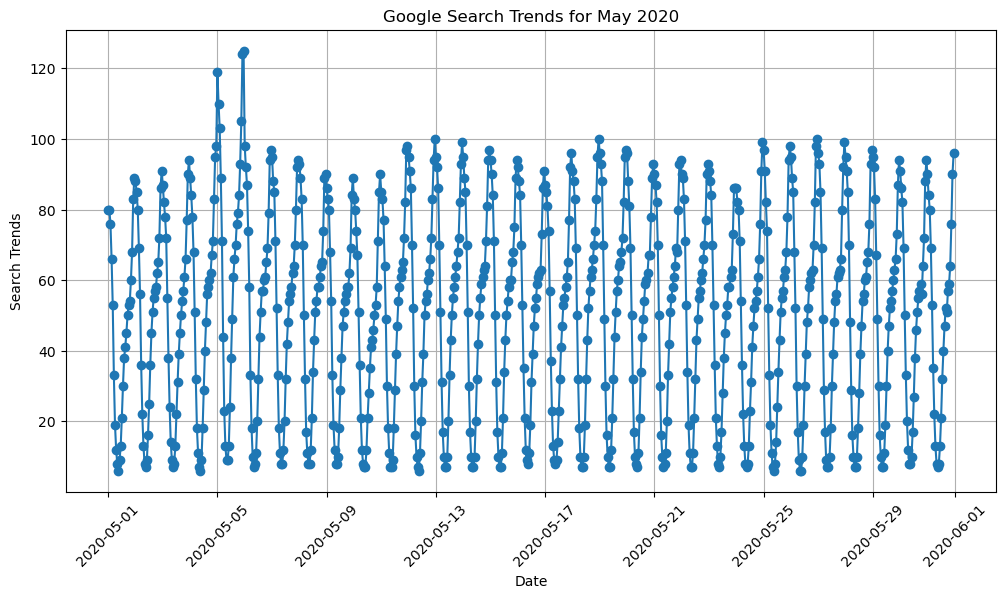

In [9]:
# Calculate the sum of the total search traffic for May 2020

total_search_traffic_may_2020 = df_may_2020['Search Trends'].sum()

# Calculate the monthly total search traffic across all months
monthly_total_search_traffic = df_mercado_trends.resample('M').sum()

# Calculate the median of the monthly total search traffic
median_monthly_total_search_traffic = monthly_total_search_traffic['Search Trends'].median()

# Determine if the search traffic increased during May 2020 compared to the monthly median
increased_search_traffic = total_search_traffic_may_2020 > median_monthly_total_search_traffic

# Print the results
print("Total search traffic for May 2020:", total_search_traffic_may_2020)
print("Median monthly total search traffic across all months:", median_monthly_total_search_traffic)
print("Did the Google search traffic increase during the month that MercadoLibre released its financial results?", increased_search_traffic)

# Plot the data for May 2020
plt.figure(figsize=(12, 6))
plt.plot(df_may_2020.index, df_may_2020['Search Trends'], marker='o', linestyle='-')
plt.title('Google Search Trends for May 2020')
plt.xlabel('Date')
plt.ylabel('Search Trends')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# View the traffic_may_2020 value


In [10]:

# Group the DataFrame by index year and then index month, chain the sum and then the median functions

median_monthly_traffic = df_mercado_trends.groupby([df_mercado_trends.index.year, df_mercado_trends.index.month]).sum().median()

# View the median_monthly_traffic value
print("Median monthly traffic value:", median_monthly_traffic['Search Trends'])



Median monthly traffic value: 35172.5


In [11]:
# Compare the seach traffic for the month of May 2020 to the overall monthly median value
#traffic_may_2020/median_monthly_traffic

increased_search_traffic = total_search_traffic_may_2020 > median_monthly_total_search_traffic

# Print the results
print("Total search traffic for May 2020:", total_search_traffic_may_2020)
print("Median monthly total search traffic across all months:", median_monthly_total_search_traffic)
print("Did the Google search traffic increase during the month that MercadoLibre released its financial results?", increased_search_traffic)


Total search traffic for May 2020: 38181
Median monthly total search traffic across all months: 35172.5
Did the Google search traffic increase during the month that MercadoLibre released its financial results? True


##### Answer the following question:

**Question:** Did the Google search traffic increase during the month that MercadoLibre released its financial results? Yes it did increase when the financials were released.

**Answer:** Yes! The search traffic did increase in May.

## Step 2: Mine the Search Traffic Data for Seasonality

Marketing realizes that they can use the hourly search data, too. If they can track and predict interest in the company and its platform for any time of day, they can focus their marketing efforts around the times that have the most traffic. This will get a greater return on investment (ROI) from their marketing budget.

To that end, you want to mine the search traffic data for predictable seasonal patterns of interest in the company. To do so, complete the following steps:

1. Group the hourly search data to plot the average traffic by the hour of day. Does the search traffic peak at a particular time of day or is it relatively consistent?

2. Group the hourly search data to plot the average traffic by the day of the week (for example, Monday vs. Friday). Does the search traffic get busiest on any particular day of the week?

3. Group the hourly search data to plot the average traffic by the week of the year. Does the search traffic tend to increase during the winter holiday period (weeks 40 through 52)?


#### Step 1: Group the hourly search data to plot the average traffic by the hour of the day.

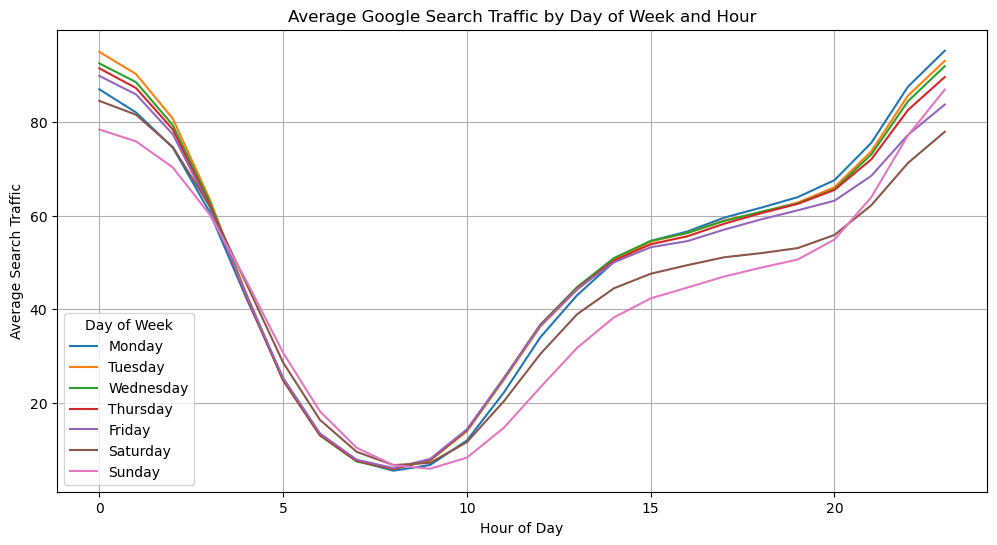

In [12]:
# Group the hourly search data to plot the average traffic by the day of week, using `df.index.hour`
# Group the hourly search data to plot the average traffic by the day of week and hour
average_traffic_by_day_hour = df_mercado_trends.groupby([df_mercado_trends.index.weekday, df_mercado_trends.index.hour]).mean()

# Unstack the dataframe to make it easier to plot
average_traffic_by_day_hour_unstacked = average_traffic_by_day_hour['Search Trends'].unstack(level=1)

# Plot the average traffic by the day of week
plt.figure(figsize=(12, 6))
for day in average_traffic_by_day_hour_unstacked.index:
    plt.plot(average_traffic_by_day_hour_unstacked.columns, average_traffic_by_day_hour_unstacked.loc[day], label=f'Day {day}')

plt.title('Average Google Search Traffic by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Search Traffic')
plt.legend(title='Day of Week', labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.grid(True)
plt.show()

#### Step 2: Group the hourly search data to plot the average traffic by the day of the week (for example, Monday vs. Friday).

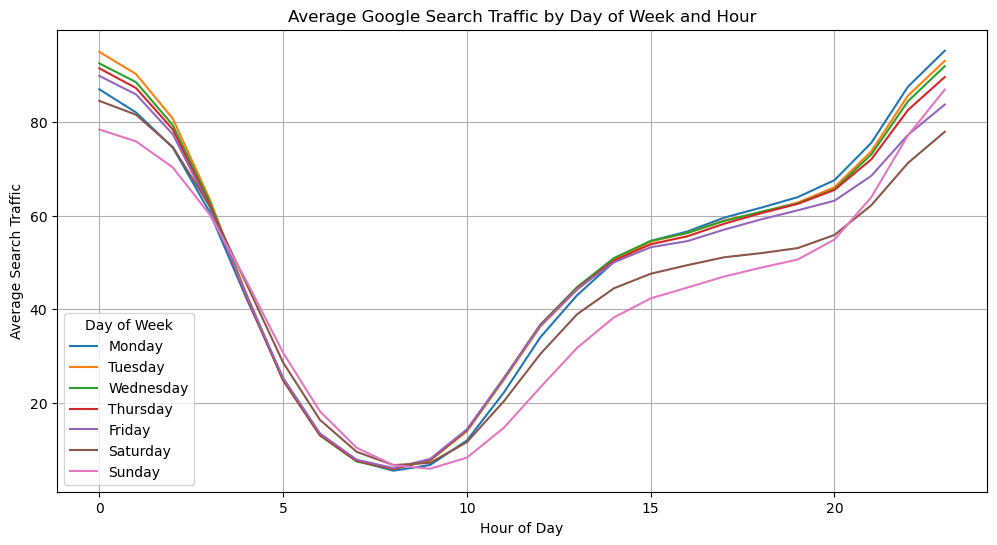

In [14]:
# Group the hourly search data to plot the average traffic by the day of week, using `df.index.isocalendar().day`.

average_traffic_by_day_hour = df_mercado_trends.groupby([df_mercado_trends.index.isocalendar().day, df_mercado_trends.index.hour]).mean()

# Unstack the dataframe to make it easier to plot
average_traffic_by_day_hour_unstacked = average_traffic_by_day_hour['Search Trends'].unstack(level=1)

# Plot the average traffic by the day of week
plt.figure(figsize=(12, 6))
for day in average_traffic_by_day_hour_unstacked.index:
    plt.plot(average_traffic_by_day_hour_unstacked.columns, average_traffic_by_day_hour_unstacked.loc[day], label=f'Day {day}')

plt.title('Average Google Search Traffic by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Search Traffic')
plt.legend(title='Day of Week', labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.grid(True)
plt.show()

#### Step 3: Group the hourly search data to plot the average traffic by the week of the year.

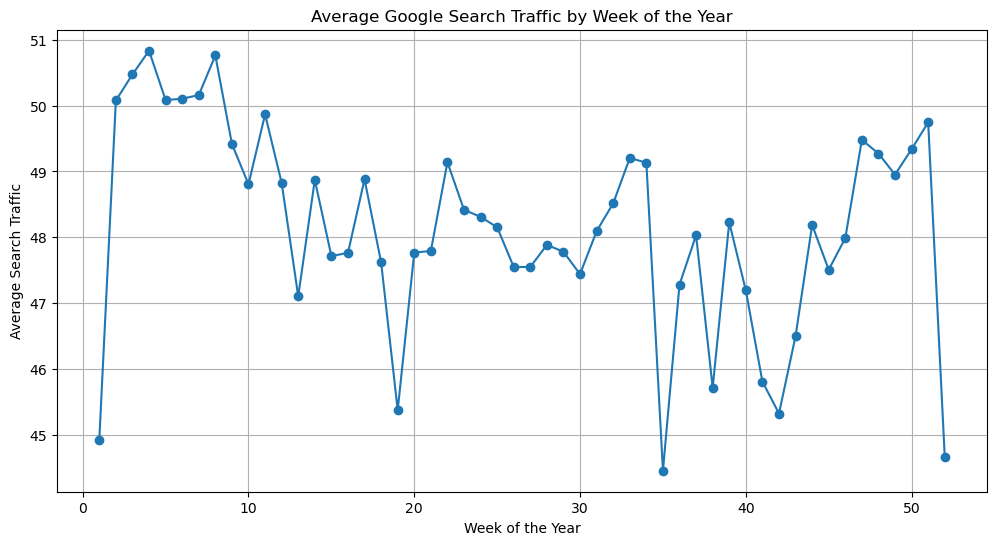

In [18]:
# Group the hourly search data to plot the average traffic by the week of the year using `df.index.isocalendar().week`.
# Group the hourly search data to plot the average traffic by the week of the year using df.index.isocalendar().week
average_traffic_by_week = df_mercado_trends.groupby(df_mercado_trends.index.isocalendar().week).mean()

# Plot the average traffic by the week of the year
plt.figure(figsize=(12, 6))
plt.plot(average_traffic_by_week.index, average_traffic_by_week['Search Trends'], marker='o', linestyle='-')
plt.title('Average Google Search Traffic by Week of the Year')
plt.xlabel('Week of the Year')
plt.ylabel('Average Search Traffic')
plt.grid(True)
plt.show()

##### Answer the following question:

**Question:** Are there any time based trends that you can see in the data?

**Answer:** yes, at the begining of the year first two months trafic is higher than the rest of weeks throughout the year.

## Step 3: Relate the Search Traffic to Stock Price Patterns

You mention your work on the search traffic data during a meeting with people in the finance group at the company. They want to know if any relationship between the search data and the company stock price exists, and they ask if you can investigate.

To do so, complete the following steps:

1. Read in and plot the stock price data. Concatenate the stock price data to the search data in a single DataFrame.

2. Market events emerged during the year of 2020 that many companies found difficult. But, after the initial shock to global financial markets, new customers and revenue increased for e-commerce platforms. Slice the data to just the first half of 2020 (`2020-01` to `2020-06` in the DataFrame), and then plot the data. Do both time series indicate a common trend that’s consistent with this narrative?

3. Create a new column in the DataFrame named “Lagged Search Trends” that offsets, or shifts, the search traffic by one hour. Create two additional columns:

    * “Stock Volatility”, which holds an exponentially weighted four-hour rolling average of the company’s stock volatility

    * “Hourly Stock Return”, which holds the percent change of the company's stock price on an hourly basis

4. Review the time series correlation, and then answer the following question: Does a predictable relationship exist between the lagged search traffic and the stock volatility or between the lagged search traffic and the stock price returns?


#### Step 1: Read in and plot the stock price data. Concatenate the stock price data to the search data in a single DataFrame.

In [15]:
# Upload the "mercado_stock_price.csv" file into Colab, then store in a Pandas DataFrame
# Set the "date" column as the Datetime Index.
df_mercado_stock = pd.read_csv(
    "https://static.bc-edx.com/ai/ail-v-1-0/m8/lms/datasets/mercado_stock_price.csv",
    index_col="date",
    parse_dates=True
).dropna()

# View the first and last five rows of the DataFrame
display(df_mercado_stock.head())
display(df_mercado_stock.tail())

,close
date,
2015-01-02 09:00:00,127.67
2015-01-02 10:00:00,125.44
2015-01-02 11:00:00,125.57
2015-01-02 12:00:00,125.40
2015-01-02 13:00:00,125.17


,close
date,
2020-07-31 11:00:00,1105.780
2020-07-31 12:00:00,1087.925
2020-07-31 13:00:00,1095.800
2020-07-31 14:00:00,1110.650
2020-07-31 15:00:00,1122.510


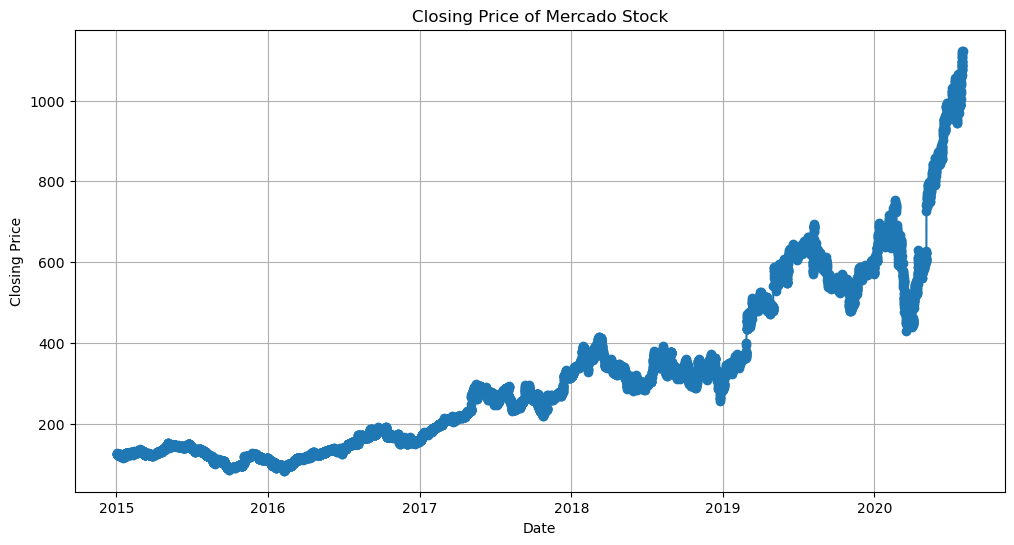

In [20]:
# Visualize the closing price of the df_mercado_stock DataFrame
# Plot the closing price of the df_mercado_stock DataFrame
plt.figure(figsize=(12, 6))
plt.plot(df_mercado_stock.index, df_mercado_stock['close'], marker='o', linestyle='-')
plt.title('Closing Price of Mercado Stock')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

In [16]:

# Concatenate the df_mercado_stock DataFrame with the df_mercado_trends DataFrame by columns (axis=1)
df_concatenated = pd.concat([df_mercado_stock, df_mercado_trends], axis=1).dropna(how='any')

# View the first five rows of the concatenated DataFrame
print("First Five Rows of Concatenated Data:")
print(df_concatenated.head())

# View the last five rows of the concatenated DataFrame
print("\nLast Five Rows of Concatenated Data:")
print(df_concatenated.tail())


First Five Rows of Concatenated Data:
                      close  Search Trends
2016-06-01 09:00:00  135.16            6.0
2016-06-01 10:00:00  136.63           12.0
2016-06-01 11:00:00  136.56           22.0
2016-06-01 12:00:00  136.42           33.0
2016-06-01 13:00:00  136.10           40.0

Last Five Rows of Concatenated Data:
                        close  Search Trends
2020-07-31 11:00:00  1105.780           20.0
2020-07-31 12:00:00  1087.925           32.0
2020-07-31 13:00:00  1095.800           41.0
2020-07-31 14:00:00  1110.650           47.0
2020-07-31 15:00:00  1122.510           53.0


#### Step 2: Market events emerged during the year of 2020 that many companies found difficult. But, after the initial shock to global financial markets, new customers and revenue increased for e-commerce platforms. Slice the data to just the first half of 2020 (`2020-01` to `2020-06` in the DataFrame), and then plot the data. Do both time series indicate a common trend that’s consistent with this narrative?

In [17]:
# For the combined dataframe, slice to just the first half of 2020 (2020-01 through 2020-06)

# View the first and last five rows of first_half_2020 DataFrame

# Slice the combined DataFrame to just the first half of 2020 (2020-01 through 2020-06)
first_half_2020 = df_concatenated.loc['2020-01-01':'2020-06-30']

# View the first five rows of the first_half_2020 DataFrame
print("First Five Rows of First Half 2020 Data:")
print(first_half_2020.head())

# View the last five rows of the first_half_2020 DataFrame
print("\nLast Five Rows of First Half 2020 Data:")
print(first_half_2020.tail())


First Five Rows of First Half 2020 Data:
                       close  Search Trends
2020-01-02 09:00:00  601.085            9.0
2020-01-02 10:00:00  601.290           14.0
2020-01-02 11:00:00  615.410           25.0
2020-01-02 12:00:00  611.400           37.0
2020-01-02 13:00:00  611.830           50.0

Last Five Rows of First Half 2020 Data:
                      close  Search Trends
2020-06-30 11:00:00  976.17           17.0
2020-06-30 12:00:00  977.50           27.0
2020-06-30 13:00:00  973.23           37.0
2020-06-30 14:00:00  976.50           45.0
2020-06-30 15:00:00  984.93           51.0


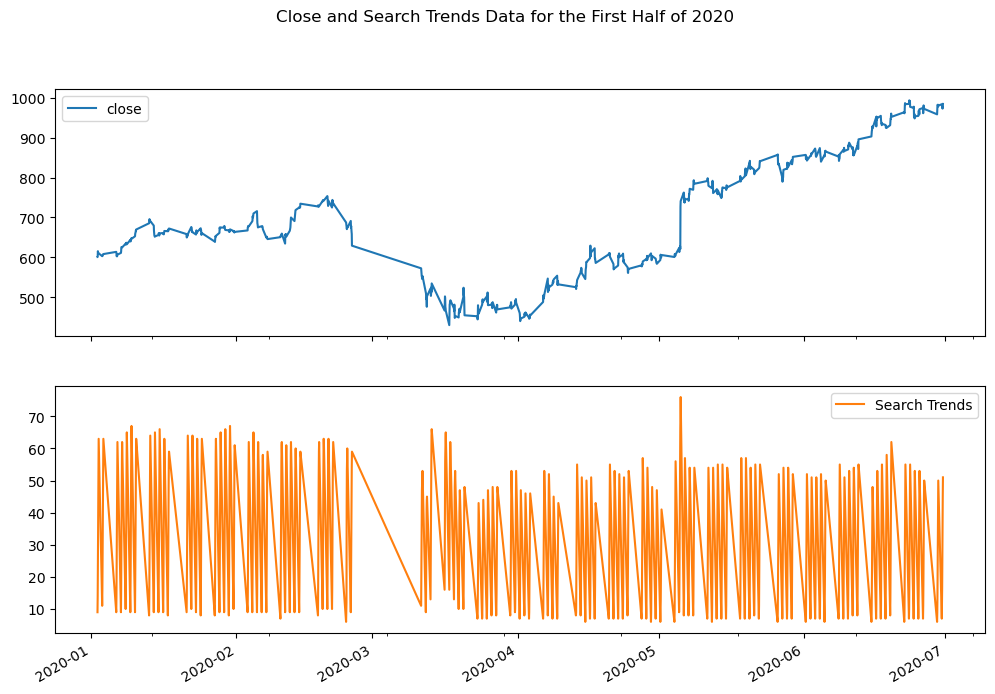

In [19]:
# Visualize the close and Search Trends data
# Plot each column on a separate axes using the following syntax
# `plot(subplots=True)`

# Visualize the close and Search Trends data
first_half_2020[['close', 'Search Trends']].plot(subplots=True, figsize=(12, 8), title='Close and Search Trends Data for the First Half of 2020')
plt.show()



##### Answer the following question:

**Question:** Do both time series indicate a common trend that’s consistent with this narrative?

**Answer:** No, they do not.

#### Step 3: Create a new column in the DataFrame named “Lagged Search Trends” that offsets, or shifts, the search traffic by one hour. Create two additional columns:

* “Stock Volatility”, which holds an exponentially weighted four-hour rolling average of the company’s stock volatility

* “Hourly Stock Return”, which holds the percent change of the company's stock price on an hourly basis


In [20]:
# Create a new column in the mercado_stock_trends_df DataFrame called Lagged Search Trends
# This column should shift the Search Trends information by one hour

# Create a new column called Lagged Search Trends that shifts the Search Trends information by one hour
df_concatenated['Lagged Search Trends'] = df_concatenated['Search Trends'].shift(1)

# View the first few rows to verify the new column
print(df_concatenated.head())


                      close  Search Trends  Lagged Search Trends
2016-06-01 09:00:00  135.16            6.0                   NaN
2016-06-01 10:00:00  136.63           12.0                   6.0
2016-06-01 11:00:00  136.56           22.0                  12.0
2016-06-01 12:00:00  136.42           33.0                  22.0
2016-06-01 13:00:00  136.10           40.0                  33.0


In [23]:
# Create a new column in the mercado_stock_trends_df DataFrame called Stock Volatility
# This column should calculate the standard deviation of the closing stock price return data over a 4 period rolling window

# Create a new column called Stock Volatility
# This column calculates the standard deviation of the closing stock price return data over a 4 period rolling window
df_concatenated['Stock Volatility'] = df_concatenated['close'].pct_change().rolling(window=4).std()

# View the first few rows to verify the new column
print(df_concatenated.head())


                      close  Search Trends  Lagged Search Trends  \
2016-06-01 09:00:00  135.16            6.0                   NaN   
2016-06-01 10:00:00  136.63           12.0                   6.0   
2016-06-01 11:00:00  136.56           22.0                  12.0   
2016-06-01 12:00:00  136.42           33.0                  22.0   
2016-06-01 13:00:00  136.10           40.0                  33.0   

                     Stock Volatility  
2016-06-01 09:00:00               NaN  
2016-06-01 10:00:00               NaN  
2016-06-01 11:00:00               NaN  
2016-06-01 12:00:00               NaN  
2016-06-01 13:00:00          0.006134  


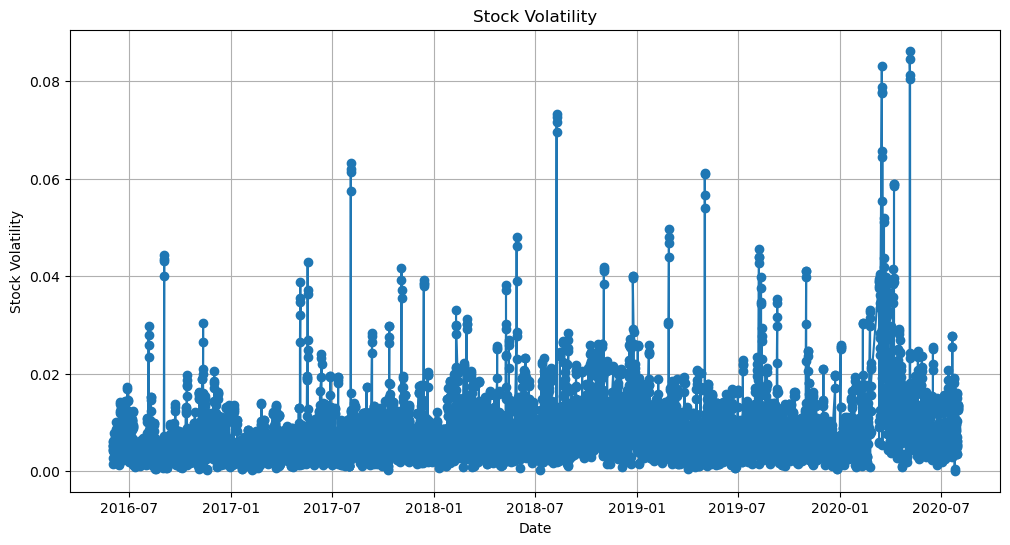

In [24]:
# Visualize the stock volatility

# Visualize the stock volatility
plt.figure(figsize=(12, 6))
plt.plot(df_concatenated.index, df_concatenated['Stock Volatility'], marker='o', linestyle='-')
plt.title('Stock Volatility')
plt.xlabel('Date')
plt.ylabel('Stock Volatility')
plt.grid(True)
plt.show()

**Solution Note:** Note how volatility spiked, and tended to stay high, during the first half of 2020. This is a common characteristic of volatility in stock returns worldwide: high volatility days tend to be followed by yet more high volatility days. When it rains, it pours.

In [26]:
# Create a new column called Hourly Stock Return
# This column calculates the hourly return percentage of the closing price
df_concatenated['Hourly Stock Return'] = df_concatenated['close'].pct_change() * 100

# View the first few rows to verify the new column
print(df_concatenated.head())

                      close  Search Trends  Lagged Search Trends  \
2016-06-01 09:00:00  135.16            6.0                   NaN   
2016-06-01 10:00:00  136.63           12.0                   6.0   
2016-06-01 11:00:00  136.56           22.0                  12.0   
2016-06-01 12:00:00  136.42           33.0                  22.0   
2016-06-01 13:00:00  136.10           40.0                  33.0   

                     Stock Volatility  Hourly Stock Return  
2016-06-01 09:00:00               NaN                  NaN  
2016-06-01 10:00:00               NaN             1.087600  
2016-06-01 11:00:00               NaN            -0.051233  
2016-06-01 12:00:00               NaN            -0.102519  
2016-06-01 13:00:00          0.006134            -0.234570  


In [29]:
# View the first and last five rows of the mercado_stock_trends_df DataFrame
# View the first five rows of the df_concatenated DataFrame
print("First Five Rows of Mercado Stock Trends Data:")
print(df_concatenated.head())

# View the last five rows of the df_concatenated DataFrame
print("\nLast Five Rows of Mercado Stock Trends Data:")
display(df_concatenated.tail())

First Five Rows of Mercado Stock Trends Data:
                      close  Search Trends  Lagged Search Trends  \
2016-06-01 09:00:00  135.16            6.0                   NaN   
2016-06-01 10:00:00  136.63           12.0                   6.0   
2016-06-01 11:00:00  136.56           22.0                  12.0   
2016-06-01 12:00:00  136.42           33.0                  22.0   
2016-06-01 13:00:00  136.10           40.0                  33.0   

                     Stock Volatility  Hourly Stock Return  
2016-06-01 09:00:00               NaN                  NaN  
2016-06-01 10:00:00               NaN             1.087600  
2016-06-01 11:00:00               NaN            -0.051233  
2016-06-01 12:00:00               NaN            -0.102519  
2016-06-01 13:00:00          0.006134            -0.234570  

Last Five Rows of Mercado Stock Trends Data:


,close,Search Trends,Lagged Search Trends,Stock Volatility,Hourly Stock Return
2020-07-31 11:00:00,1105.780,20.0,11.0,0.012837,0.637986
2020-07-31 12:00:00,1087.925,32.0,20.0,0.013549,-1.614697
2020-07-31 13:00:00,1095.800,41.0,32.0,0.013295,0.723855
2020-07-31 14:00:00,1110.650,47.0,41.0,0.013001,1.355174
2020-07-31 15:00:00,1122.510,53.0,47.0,0.013566,1.067843


#### Step 4: Review the time series correlation, and then answer the following question: Does a predictable relationship exist between the lagged search traffic and the stock volatility or between the lagged search traffic and the stock price returns?

In [31]:
# Construct the correlation table of Stock Volatility, Lagged Search Trends, and Hourly Stock Return
correlation_table = df_concatenated[['Stock Volatility', 'Lagged Search Trends', 'Hourly Stock Return']].corr()

# Display the correlation table
display(correlation_table)


,Stock Volatility,Lagged Search Trends,Hourly Stock Return
Stock Volatility,1.000000,-0.148938,0.061424
Lagged Search Trends,-0.148938,1.000000,0.017929
Hourly Stock Return,0.061424,0.017929,1.000000


##### Answer the following question:


**Question:** Does a predictable relationship exist between the lagged search traffic and the stock volatility or between the lagged search traffic and the stock price returns?

**Answer:** At the moment we can see that there is NO correlations.

## Step 4: Create a Time Series Model with Prophet

Now, you need to produce a time series model that analyzes and forecasts patterns in the hourly search data. To do so, complete the following steps:

1. Set up the Google search data for a Prophet forecasting model.

2. After estimating the model, plot the forecast. How's the near-term forecast for the popularity of MercadoLibre?

3. Plot the individual time series components of the model to answer the following questions:

    * What time of day exhibits the greatest popularity?

    * Which day of the week gets the most search traffic?

    * What's the lowest point for search traffic in the calendar year?


#### Step 1: Set up the Google search data for a Prophet forecasting model.

In [32]:
# Reset the index so the date information is no longer the index
prophet_df = df_mercado_trends.reset_index()

# Label the columns ds and y so that the syntax is recognized by Prophet
prophet_df.columns = ['ds', 'y']

# Drop any NaN values from the prophet_df DataFrame
prophet_df = prophet_df.dropna()

# View the first five rows of the prophet_df DataFrame
print("First Five Rows of Prophet Data:")
print(prophet_df.head())

# View the last five rows of the prophet_df DataFrame
print("\nLast Five Rows of Prophet Data:")
print(prophet_df.tail())






First Five Rows of Prophet Data:
                   ds   y
0 2016-06-01 00:00:00  97
1 2016-06-01 01:00:00  92
2 2016-06-01 02:00:00  76
3 2016-06-01 03:00:00  60
4 2016-06-01 04:00:00  38

Last Five Rows of Prophet Data:
                       ds   y
37101 2020-09-07 20:00:00  71
37102 2020-09-07 21:00:00  83
37103 2020-09-07 22:00:00  96
37104 2020-09-07 23:00:00  97
37105 2020-09-08 00:00:00  96


In [33]:

!pip install prophet

# Import Prophet
from prophet import Prophet


In [34]:


# Load the dataset
df_mercado_trends = pd.read_csv(
    "https://static.bc-edx.com/ai/ail-v-1-0/m8/lms/datasets/google_hourly_search_trends.csv",
    index_col='Date',
    parse_dates=True
).dropna()

# Reset the index so the date information is no longer the index
prophet_df = df_mercado_trends.reset_index()

# Label the columns ds and y so that the syntax is recognized by Prophet
prophet_df.columns = ['ds', 'y']

# Drop any NaN values from the prophet_df DataFrame
prophet_df = prophet_df.dropna()

# Call the Prophet function and store it as an object
model = Prophet()

# Fit the model
model.fit(prophet_df)

# View the first few rows to ensure proper loading
print(prophet_df.head())

/var/folders/zg/f4h5h8796cgbm5xkdx030gjh0000gn/T/ipykernel_89999/3280232977.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_mercado_trends = pd.read_csv(
22:16:33 - cmdstanpy - INFO - Chain [1] start processing
22:16:40 - cmdstanpy - INFO - Chain [1] done processing


                   ds   y
0 2016-06-01 00:00:00  97
1 2016-06-01 01:00:00  92
2 2016-06-01 02:00:00  76
3 2016-06-01 03:00:00  60
4 2016-06-01 04:00:00  38


In [35]:
# Fit the time-series model.

# Call the Prophet function and store it as an object
model = Prophet()

# Fit the model
model.fit(prophet_df)


22:16:51 - cmdstanpy - INFO - Chain [1] start processing
22:16:58 - cmdstanpy - INFO - Chain [1] done processing


In [36]:
# Create a future dataframe to hold predictions
# Make the prediction go out as far as 2000 hours (approx 80 days)


# View the last five rows of the future_mercado_trends DataFrame

# Create a future dataframe to hold predictions, extending out 2000 hours
future_mercado_trends = model.make_future_dataframe(periods=2000, freq='H')

# View the last five rows of the future_mercado_trends DataFrame
print("Last Five Rows of Future DataFrame:")
print(future_mercado_trends.tail())


Last Five Rows of Future DataFrame:
                       ds
39101 2020-11-30 04:00:00
39102 2020-11-30 05:00:00
39103 2020-11-30 06:00:00
39104 2020-11-30 07:00:00
39105 2020-11-30 08:00:00


/opt/anaconda3/envs/dev/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [37]:
# Make the predictions for the trend data using the future_mercado_trends DataFrame
forecast_mercado_trends = model.predict(future_mercado_trends)

# Display the first five rows of the forecast_mercado_trends DataFrame
print("First Five Rows of Forecast DataFrame:")
display(forecast_mercado_trends.head())


First Five Rows of Forecast DataFrame:


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2016-06-01 00:00:00,44.275375,81.045074,98.135302,44.275375,44.275375,45.309572,45.309572,45.309572,41.452721,...,1.860328,1.860328,1.860328,1.996523,1.996523,1.996523,0.0,0.0,0.0,89.584947
1,2016-06-01 01:00:00,44.276378,77.608388,94.131637,44.276378,44.276378,41.755341,41.755341,41.755341,37.943520,...,1.810240,1.810240,1.810240,2.001582,2.001582,2.001582,0.0,0.0,0.0,86.031720
2,2016-06-01 02:00:00,44.277382,67.436133,84.106581,44.277382,44.277382,31.431828,31.431828,31.431828,27.656558,...,1.768661,1.768661,1.768661,2.006609,2.006609,2.006609,0.0,0.0,0.0,75.709210
3,2016-06-01 03:00:00,44.278385,51.319963,68.792993,44.278385,44.278385,16.164591,16.164591,16.164591,12.417303,...,1.735683,1.735683,1.735683,2.011605,2.011605,2.011605,0.0,0.0,0.0,60.442977
4,2016-06-01 04:00:00,44.279389,35.332602,51.522447,44.279389,44.279389,-0.950297,-0.950297,-0.950297,-4.678130,...,1.711263,1.711263,1.711263,2.016569,2.016569,2.016569,0.0,0.0,0.0,43.329091


#### Step 2: After estimating the model, plot the forecast. How's the near-term forecast for the popularity of MercadoLibre?

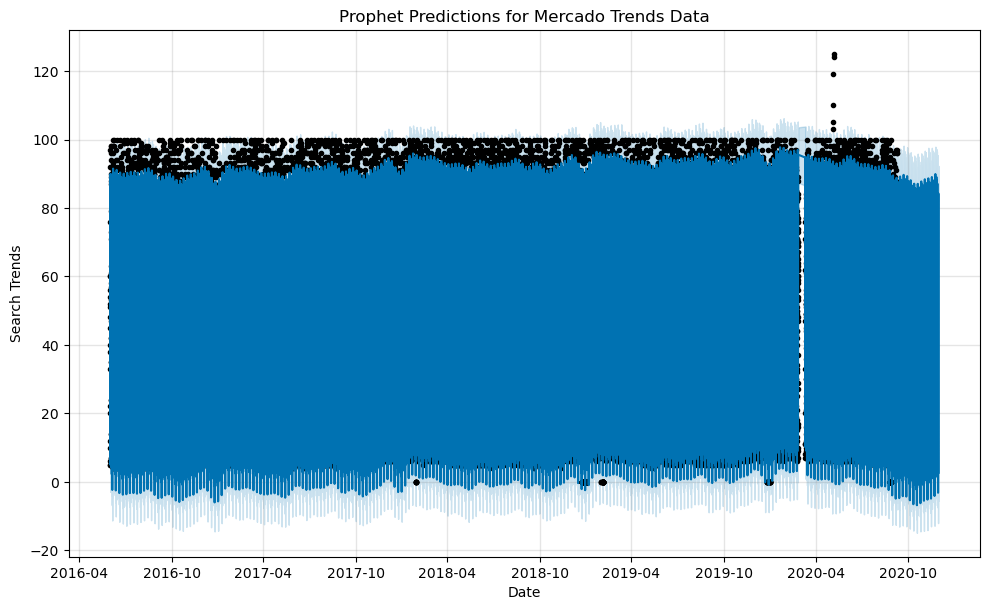

In [39]:
# Plot the Prophet predictions for the Mercado trends data
# Plot the Prophet predictions for the Mercado trends data
fig = model.plot(forecast_mercado_trends)
plt.title('Prophet Predictions for Mercado Trends Data')
plt.xlabel('Date')
plt.ylabel('Search Trends')
plt.show()


##### Answer the following question:

**Question:**  How's the near-term forecast for the popularity of MercadoLibre?

**Answer:** the near-term forecast is good


#### Step 3: Plot the individual time series components of the model to answer the following questions:

* What time of day exhibits the greatest popularity?

* Which day of the week gets the most search traffic?

* What's the lowest point for search traffic in the calendar year?


In [41]:
# Set the index in the forecast_mercado_trends DataFrame to the ds datetime column

# View the only the yhat,yhat_lower and yhat_upper columns from the DataFrame


# Make the predictions for the trend data using the future_mercado_trends DataFrame
forecast_mercado_trends = model.predict(future_mercado_trends)

# Set the index in the forecast_mercado_trends DataFrame to the ds datetime column
forecast_mercado_trends.set_index('ds', inplace=True)

# View only the yhat, yhat_lower, and yhat_upper columns from the DataFrame
forecast_subset = forecast_mercado_trends[['yhat', 'yhat_lower', 'yhat_upper']]

# Display the first and last five rows of the forecast subset
print("First Five Rows of Forecast Subset:")
print(forecast_subset.head())

print("\nLast Five Rows of Forecast Subset:")
print(forecast_subset.tail())


First Five Rows of Forecast Subset:
                          yhat  yhat_lower  yhat_upper
ds                                                    
2016-06-01 00:00:00  89.584947   81.424739   97.836829
2016-06-01 01:00:00  86.031720   77.876684   94.310311
2016-06-01 02:00:00  75.709210   67.376661   83.740861
2016-06-01 03:00:00  60.442977   52.133079   69.888901
2016-06-01 04:00:00  43.329091   34.880449   51.894129

Last Five Rows of Forecast Subset:
                          yhat  yhat_lower  yhat_upper
ds                                                    
2020-11-30 04:00:00  39.531447   30.969630   48.627136
2020-11-30 05:00:00  24.060279   15.728697   32.592747
2020-11-30 06:00:00  12.094580    3.347408   20.428896
2020-11-30 07:00:00   4.822400   -3.517171   13.311490
2020-11-30 08:00:00   2.627492   -6.388749   11.096177


Solutions Note: `yhat` represents the most likely (average) forecast, whereas `yhat_lower` and `yhat_upper` represents the worst and best case prediction (based on what are known as 95% confidence intervals).

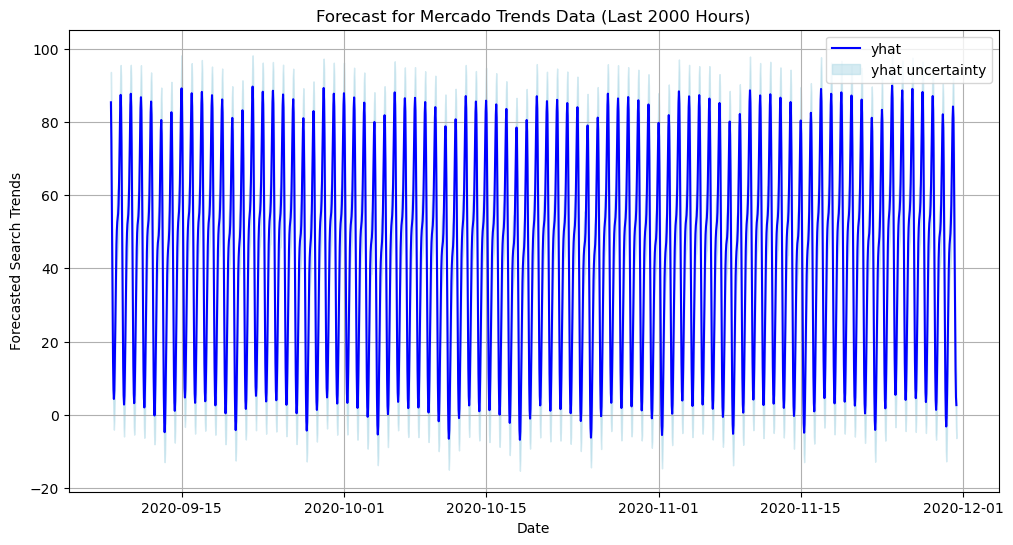

In [43]:
# From the forecast_mercado_trends DataFrame, plot the data to visualize
#  the yhat, yhat_lower, and yhat_upper columns over the last 2000 hours

import matplotlib.pyplot as plt

# Plot the yhat, yhat_lower, and yhat_upper columns over the last 2000 hours
plt.figure(figsize=(12, 6))
plt.plot(forecast_subset.index[-2000:], forecast_subset['yhat'][-2000:], label='yhat', color='blue')
plt.fill_between(forecast_subset.index[-2000:], 
                 forecast_subset['yhat_lower'][-2000:], 
                 forecast_subset['yhat_upper'][-2000:], 
                 color='lightblue', alpha=0.5, label='yhat uncertainty')
plt.title('Forecast for Mercado Trends Data (Last 2000 Hours)')
plt.xlabel('Date')
plt.ylabel('Forecasted Search Trends')
plt.legend()
plt.grid(True)
plt.show()


/var/folders/zg/f4h5h8796cgbm5xkdx030gjh0000gn/T/ipykernel_89999/420217788.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_mercado_trends = pd.read_csv(
22:42:46 - cmdstanpy - INFO - Chain [1] start processing
22:42:53 - cmdstanpy - INFO - Chain [1] done processing
/opt/anaconda3/envs/dev/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(
/opt/anaconda3/envs/dev/lib/python3.10/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/opt/anaconda3/envs/dev/li

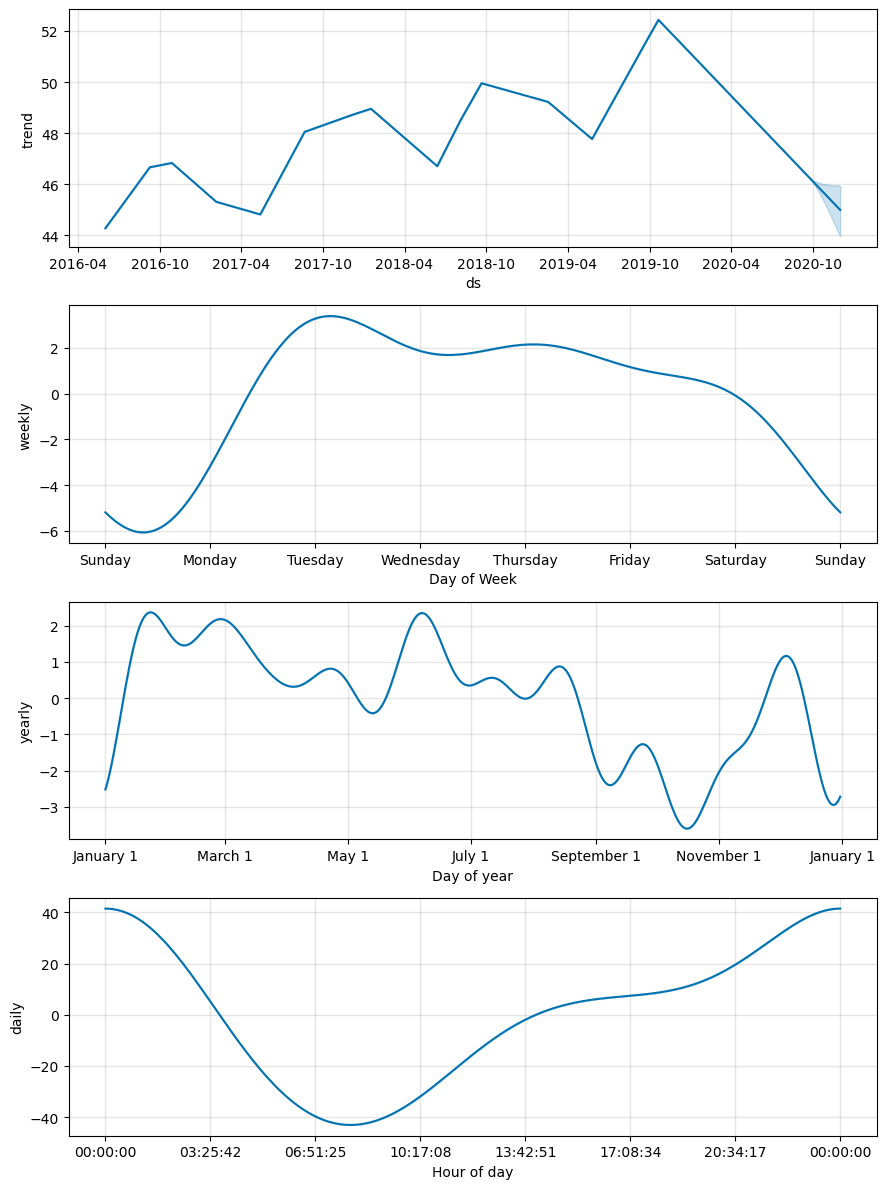

In [42]:
# Reset the index in the forecast_mercado_trends DataFrame

# Use the plot_components function to visualize the forecast results
# for the forecast_canada DataFrame


import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Load the dataset
df_mercado_trends = pd.read_csv(
    "https://static.bc-edx.com/ai/ail-v-1-0/m8/lms/datasets/google_hourly_search_trends.csv",
    index_col='Date',
    parse_dates=True
).dropna()

# Reset the index so the date information is no longer the index
prophet_df = df_mercado_trends.reset_index()

# Label the columns ds and y so that the syntax is recognized by Prophet
prophet_df.columns = ['ds', 'y']

# Drop any NaN values from the prophet_df DataFrame
prophet_df = prophet_df.dropna()

# Call the Prophet function and store it as an object
model = Prophet()

# Fit the model
model.fit(prophet_df)

# Create a future dataframe to hold predictions, extending out 2000 hours
future_mercado_trends = model.make_future_dataframe(periods=2000, freq='H')

# Make the predictions for the trend data using the future_mercado_trends DataFrame
forecast_mercado_trends = model.predict(future_mercado_trends)

# Reset the index in the forecast_mercado_trends DataFrame
forecast_mercado_trends.reset_index(drop=True, inplace=True)

# Use the plot_components function to visualize the forecast results
fig = model.plot_components(forecast_mercado_trends)
plt.show()


##### Answer the following questions:

**Question:** What time of day exhibits the greatest popularity?

**Answer:** the night time, like from midnight to 3am and from 8pm to midnight

**Question:** Which day of week gets the most search traffic?
   
**Answer:** Tuesday gets the most search during the week

**Question:** What's the lowest point for search traffic in the calendar year?

**Answer:** lowest traffic is in October
